# Data Re-uploading VQC

The week 4 VQC has the same setup as the original VQC, but the circuit utilizes data reuploading to reapply the angle embedding each layer.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

np.random.seed(1234)

## Load, reduce, and split the data


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_scaled = StandardScaler().fit_transform(X)
X = PCA(n_components=2).fit_transform(X_scaled)
y = y * 2 - 1 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## Scale features for angle encoding


In [3]:
scaler = MinMaxScaler((-np.pi, np.pi)).fit(Xtr)
Xtr = scaler.transform(Xtr)
Xte = np.clip(scaler.transform(Xte), -np.pi, np.pi)

Xtr = pnp.array(Xtr)
ytr = pnp.array(ytr, dtype=float)

## Create the data-reuploading circuit

Takes the circuit and applies the angle embedding at the beginning of each of the 3 layers.

In [ ]:
n_qubits = 2
n_layers = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, diff_method="backprop")
def circuit(weights, x):
    for L in range(n_layers):
        qml.AngleEmbedding(x, wires=range(n_qubits))     
        for i in range(n_qubits):
            qml.Rot(weights[L, i, 0], weights[L, i, 1], weights[L, i, 2], wires=i)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def model(weights, bias, x):
    return circuit(weights, x) + bias

## Circuit diagram

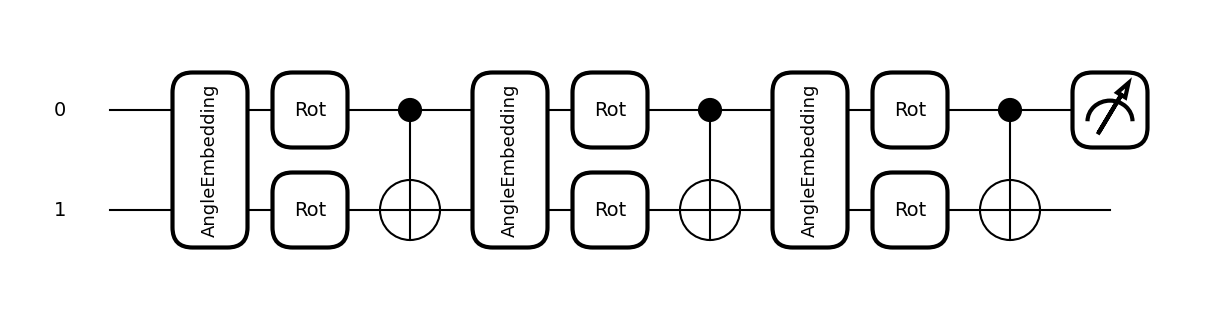

In [6]:
sample = Xtr[0]
fig, ax = qml.draw_mpl(circuit)(pnp.zeros((n_layers, n_qubits, 3)), sample)
plt.show()

## Train the model

Adjusts the circuit weights by using separate weights for each of the 3 layers to lower the loss, and save the loss each step to plot.

In [8]:
def cost(weights, bias, X, Y):
    preds = pnp.stack([model(weights, bias, x) for x in X])
    return pnp.mean((Y - preds) ** 2)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)
opt = qml.NesterovMomentumOptimizer(0.2)

loss_history = []
for step in range(40):
    weights, bias, _, _ = opt.step(cost, weights, bias, Xtr, ytr)
    loss_history.append(float(cost(weights, bias, Xtr, ytr)))

print("final training loss:", round(loss_history[-1], 4))

final training loss: 0.2123


## Training-loss plot

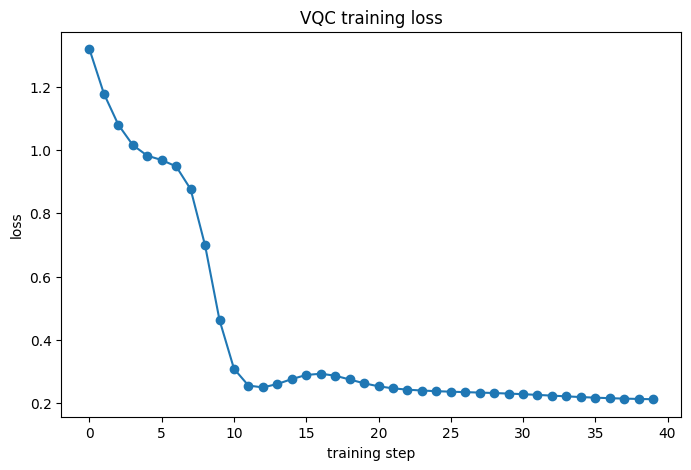

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, marker="o")
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("VQC training loss")
plt.show()

## Evaluate the model
Use the sign of the model's output to predict malignant vs benign, then compute accuracy, precision, recall, and F1.

In [10]:
def predict(X):
    return np.array([1 if model(weights, bias, x) > 0 else -1 for x in X])

pred = predict(Xte)

y_true = np.where(yte == -1, 0, 1)
y_pred = np.where(pred == -1, 0, 1)

results = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "score": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
    ],
})
results

,metric,score
0,accuracy,0.916084
1,precision,0.943182
2,recall,0.922222
3,f1,0.932584
